In [1]:
## IMPORTS AND SETUP
# Imports
import matplotlib.pyplot as plt
import numpy as np
import os
import tensorflow as tf
import datetime
import zipfile
import pandas as pd
from PIL import Image
import tensorflow_datasets as tfds


# Forcer TensorFlow à utiliser le GPU
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

    
# Tensorboard setup
%load_ext tensorboard
log_dir = "/workspace/logs/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = tf.keras.callbacks.TensorBoard(
    log_dir=log_dir,
    histogram_freq=1,
    write_graph=True,
    update_freq='epoch'
)

delete_invalid = False

2025-04-04 12:53:47.281501: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-04 12:53:47.320918: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-04-04 12:53:47.346205: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-04-04 12:53:47.355860: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-04-04 12:53:47.432096: I tensorflow/core/platform/cpu_feature_guar

In [ ]:
def fix_corrupted_images(directory):
    """
    Walks through a directory to detect and fix misformatted image files.
    PNG or GIF files mislabelled as JPG are corrected.
    """
    print(f"Checking directory: {directory}")
    if not os.path.isdir(directory):
        print(f"Directory {directory} doesn't exist")
        return
    else:
        print(f"Directory {directory} exists")

    stats = {"processed": 0, "png_fixed": 0, "gif_fixed": 0, "invalid_removed": 0, "errors": 0}

    for root, dirs, files in os.walk(directory):
        for file in files:
            file_path = os.path.join(root, file)
            stem, extension = os.path.splitext(file)

            if extension.lower() != '.jpg':
                continue

            stats["processed"] += 1

            try:
                with open(file_path, 'rb') as f:
                    header = f.read(4)

                if header[:4] == b'\x89PNG':
                    print(f"PNG detected: {file_path}")
                    new_path = os.path.join(root, f"{stem}.png")
                    os.rename(file_path, new_path)
                    Image.open(new_path).convert('RGB').save(file_path, "JPEG")
                    os.remove(new_path)
                    stats["png_fixed"] += 1

                elif header[:3] == b'GIF':
                    print(f"GIF detected: {file_path}")
                    new_path = os.path.join(root, f"{stem}.gif")
                    os.rename(file_path, new_path)
                    Image.open(new_path).convert('RGB').save(file_path, "JPEG")
                    os.remove(new_path)
                    stats["gif_fixed"] += 1

                elif header[:2] != b'\xff\xd8':
                    print(f"Non-JPEG file detected: {file_path}")
                    if delete_invalid:
                        os.remove(file_path)
                        stats["invalid_removed"] += 1

            except Exception as e:
                print(f"Error processing {file_path}: {e}")
                stats["errors"] += 1
                if delete_invalid:
                    os.remove(file_path)
                    stats["invalid_removed"] += 1

    print(f"\nSummary:")
    print(f"Files processed: {stats['processed']}")
    print(f"PNG files fixed: {stats['png_fixed']}")
    print(f"GIF files fixed: {stats['gif_fixed']}")
    print(f"Invalid files removed: {stats['invalid_removed']}")
    print(f"Errors encountered: {stats['errors']}")

fix_corrupted_images("../Dataset")

In [4]:
# Paramètres
path = "../Dataset"
excluded_folder = "Dataset Livrable 2"  # Dossier à exclure
batch_size = 12
img_height = 128
img_width = 128

In [5]:



# Vérifier le chemin et le contenu
print(f"Chemin absolu : {os.path.abspath(path)}")
if not os.path.exists(path):
    raise ValueError("Le chemin spécifié n'existe pas.")
else:
    print(f"Contenu du dossier principal : {os.listdir(path)}")

# Exclure le dossier spécifié
subfolders = [f for f in os.listdir(path) if os.path.isdir(os.path.join(path, f)) and f != excluded_folder]
print(f"Sous-dossiers utilisés pour le dataset : {subfolders}")

# Créer un dataset optimisé à partir du répertoire
try:
    dataset = tf.keras.utils.image_dataset_from_directory(
        path,
        labels="inferred",  # Les labels sont inférés à partir des noms des sous-dossiers
        label_mode="int",  # Labels sous forme d'entiers
        class_names=subfolders,  # Spécifier les classes à inclure
        color_mode="rgb",  # Images en RGB
        batch_size=batch_size,
        image_size=(img_height, img_width),  # Redimensionner les images
        shuffle=True,
        seed=123,
        validation_split=None,  # Pas de validation split ici
        subset=None,
        interpolation="bilinear",
        follow_links=False
    )

    # Afficher les classes détectées
    class_names = dataset.class_names
    print(f"Classes détectées : {class_names}")

    # Précharger les données pour une meilleure performance
    dataset = dataset.prefetch(buffer_size=tf.data.AUTOTUNE)

    # Afficher un exemple
    for images, labels in dataset.take(1):
        print(f"Images batch shape : {images.shape}")
        print(f"Labels batch : {labels.numpy()}")

except Exception as e:
    print(f"Erreur lors de la création du dataset : {e}")

Chemin absolu : /tf/projet/Dataset
Contenu du dossier principal : ['Dataset Livrable 2', 'Painting', 'Photo', 'Schematics', 'Sketch', 'Text']
Sous-dossiers utilisés pour le dataset : ['Painting', 'Photo', 'Schematics', 'Sketch', 'Text']
Found 41398 files belonging to 5 classes.


I0000 00:00:1743771412.361287     485 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1743771412.361370     485 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1743771412.361381     485 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1743771412.587290     485 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1743771412.587562     485 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-04-04

Classes détectées : ['Painting', 'Photo', 'Schematics', 'Sketch', 'Text']
Images batch shape : (12, 128, 128, 3)
Labels batch : [4 4 4 1 4 1 1 0 1 1 1 0]


2025-04-04 12:56:54.050084: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [3]:
# Proportions des splits
train_split = 0.8
val_split = 0.1
test_split = 0.1

# Calculer les tailles
dataset_size = tf.data.experimental.cardinality(dataset).numpy()  # Plus rapide que len(dataset)
train_size = int(train_split * dataset_size)
val_size = int(val_split * dataset_size)
test_size = dataset_size - train_size - val_size

# Mélanger le dataset
dataset = dataset.shuffle(buffer_size=1000, seed=123)

# Diviser le dataset
train_ds = dataset.take(train_size)
remaining_ds = dataset.skip(train_size)
val_ds = remaining_ds.take(val_size)
test_ds = remaining_ds.skip(val_size)



In [3]:
## MODEL CREATION

def create_model(img_height = 180, img_width = 180, num_classes = 5):
    model = tf.keras.Sequential([
        tf.keras.layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)),
        tf.keras.layers.Conv2D(16, 3, padding='same', activation='relu'),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Conv2D(32, 3, padding='same', activation='relu'),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Conv2D(64, 3, padding='same', activation='relu'),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(num_classes)
        ])
    
    model.compile(optimizer='adam',
                  loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                  metrics=['accuracy'])
                  
    return model

model = create_model(img_height, img_width, len(class_names))


NameError: name 'img_height' is not defined

2025-04-03 09:39:37.915745: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:10: Filling up shuffle buffer (this may take a while): 541 of 1000
2025-04-03 09:39:49.987478: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:480] Shuffle buffer filled.


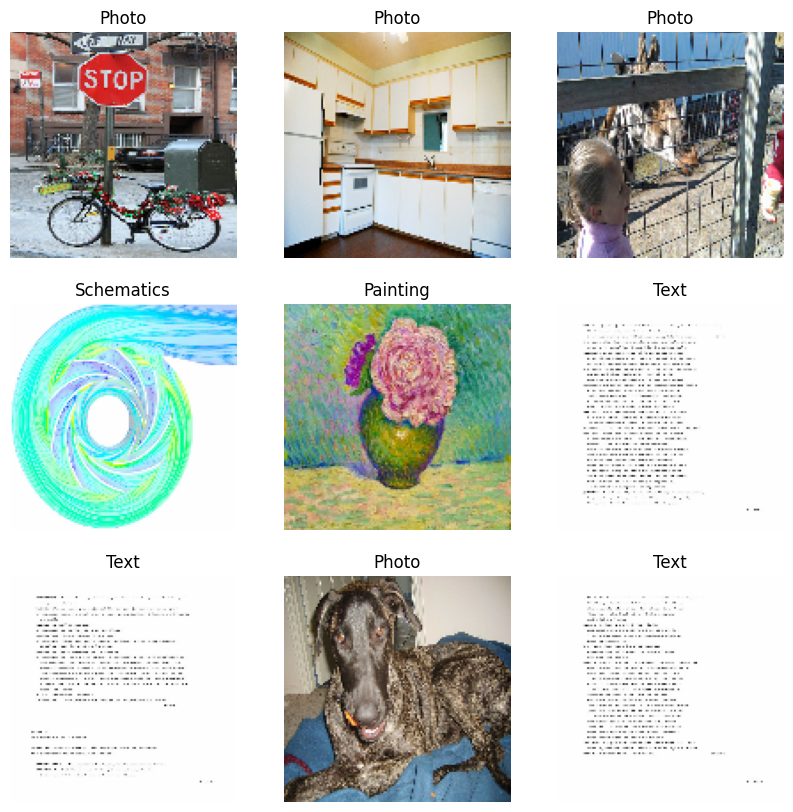

In [5]:
plt.figure(figsize=(10, 10))

# Re-initialize the dataset iterator
train_ds_iter = iter(train_ds)  # Create a fresh iterator from the dataset

# Fetch one batch of images and labels
images, labels = next(train_ds_iter)

# Display up to 9 images
for i in range(min(9, len(images))):  # Limit to 9 images
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

In [ ]:
model.summary()

In [6]:
# Définir le répertoire des logs pour TensorBoard
import datetime

def create_callbacks(model_name="default_model", tensorboard=True, early_stopping=True, model_checkpoint=True):
    # Répertoire des logs pour TensorBoard
    log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
    tensorboard_callback = None
    if tensorboard:
        tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)

    # Définir le callback EarlyStopping
    early_stopping_callback = None
    if early_stopping:
        early_stopping_callback = tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',  # Surveiller la perte de validation
            patience=4,          # Arrêter si aucune amélioration après 4 époques
            restore_best_weights=True  # Restaurer les poids du meilleur modèle
        )

    # Définir le callback ModelCheckpoint
    model_checkpoint_callback = None
    if model_checkpoint:
        checkpoint_dir = "checkpoints"
        os.makedirs(checkpoint_dir, exist_ok=True)  # Créer le dossier si nécessaire
        # Ajouter un horodatage au nom du modèle
        timestamp = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
        model_checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
            filepath=os.path.join(checkpoint_dir, f"{model_name}_{timestamp}.keras"),  # Nom personnalisé avec horodatage
            monitor='val_loss',  # Surveiller la perte de validation
            save_best_only=True,  # Sauvegarder uniquement le meilleur modèle
            verbose=1            # Afficher les logs lors de la sauvegarde
        )
    
    return tensorboard_callback, early_stopping_callback, model_checkpoint_callback


In [ ]:
epochs=10
history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs,
  
  callbacks = create_callbacks(model_name="CNN_Model")
)


Epoch 1/10


2025-04-03 09:40:51.266760: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:1641] failed to alloc 4294967296 bytes on host: CUDA_ERROR_OUT_OF_MEMORY: out of memory
2025-04-03 09:40:51.267997: W external/local_xla/xla/stream_executor/integrations/device_host_allocator.h:61] could not allocate pinned host memory of size: 4294967296
2025-04-03 09:40:51.269080: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:1641] failed to alloc 3865470464 bytes on host: CUDA_ERROR_OUT_OF_MEMORY: out of memory
2025-04-03 09:40:51.269098: W external/local_xla/xla/stream_executor/integrations/device_host_allocator.h:61] could not allocate pinned host memory of size: 3865470464
2025-04-03 09:40:51.269274: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:1641] failed to alloc 3478923264 bytes on host: CUDA_ERROR_OUT_OF_MEMORY: out of memory
2025-04-03 09:40:51.269294: W external/local_xla/xla/stream_executor/integrations/device_host_allocator.h:61] could not allocate pinn

 528/2760 ━━━━━━━━━━━━━━━━━━━━ 50s 23ms/step - accuracy: 0.6220 - loss: 0.8578

Corrupt JPEG data: 419 extraneous bytes before marker 0xd9


2760/2760 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7514 - loss: 0.5828

...

2025-04-03 09:43:52.136350: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:10: Filling up shuffle buffer (this may take a while): 493 of 1000
2025-04-03 09:44:01.495197: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:480] Shuffle buffer filled.
2025-04-03 09:44:01.498982: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 2359552 bytes after encountering the first element of size 2359552 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


 524/2760 ━━━━━━━━━━━━━━━━━━━━ 52s 23ms/step - accuracy: 0.8801 - loss: 0.3039

Corrupt JPEG data: 419 extraneous bytes before marker 0xd9


2752/2760 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8821 - loss: 0.2965

2025-04-03 09:45:05.452519: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:10: Filling up shuffle buffer (this may take a while): 485 of 1000
2025-04-03 09:45:18.317647: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:480] Shuffle buffer filled.
Corrupt JPEG data: 419 extraneous bytes before marker 0xd9


In [1]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(history.epoch))

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.ylim(0, 1)
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()


NameError: name 'history' is not defined

In [ ]:
%tensorboard --logdir ./logs/fit --reload_interval 5

In [2]:
model.load_weights("checkpoints/CNN_Model_20250403-083598.keras")

NameError: name 'model' is not defined